# Authors
- Raphael Wäspi (18-918-938)
- Nicolas Huber (16-936-205)

In [1]:
import math
# Imports
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
import glob
import re
import random
from statistics import mean

import scipy.special
from tqdm import tqdm
import shutil
from joblib import Parallel, delayed
from scipy.special import factorial
import powerlaw
from NEMtropy import UndirectedGraph


In [2]:
# Define colors with reduced opacity from a colormap
COLOR_BLUE = 'dodgerblue'
COLOR_RED = 'lightcoral'
COLOR_GREY = 'slategrey'
COLOR_BLACK = 'black'
COLOR_LIGHT_GRAY = 'lightgray'
COLOR_DARK_GRAY = 'darkgray'

# Define the main data directory
OUTPUT_PATH = "./output"

In [3]:
# Prepare output folder

# Delete the entire 'output' directory and its contents
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

# Create the 'output' directory
os.makedirs(OUTPUT_PATH)

# Define subdirectories
OUTPUT_PATH_ER = os.path.join(OUTPUT_PATH, "erdos_renyi_avg_clustering")


# Recreate the subdirectories
os.makedirs(OUTPUT_PATH_ER)

In [4]:
# Define the directory containing the .gml files
directory = 'assignment_03_data'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.gml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()
            
            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.gml$', file_path)
            if match:
                graph_name = match.group(1)
                
                # Add to the graph dictionary
                graph = nx.read_gml(file_path)
                graphs[graph_name] = graph
                
                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")
                
        pbar.update(1)  # Update the progress bar

Loading GML Files:  50%|█████     | 1/2 [00:00<00:00,  5.78it/s]

Finished loading graph_eu_airlines


Loading GML Files: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s]

Finished loading graph_power


In [5]:
# Define the directory containing the .gml files
directory = 'assignment_03_data/World_Trade_Web'

# Use glob to get a list of all .gml files in the directory
gml_files = glob.glob(os.path.join(directory, '*.graphml'))

# Init an empty dictionary for all graphs - the key is the actual name, and the value is the graph data
graphs_wtn = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(gml_files), desc="Loading GML WTW Files") as pbar:
    # Loop through the list of .gml files and load them
    for file_path in gml_files:
        with open(file_path, 'r') as file:
            content = file.read()

            # Use regex to extract the desired part
            match = re.search(r'/([^/]+)\.txt.graphml$', file_path)
            if match:
                graph_name = match.group(1)

                # Add to the graph dictionary
                graph = nx.read_graphml(file_path)
                graphs_wtn[graph_name] = graph

                # Print the graph name when each part is finished
                print(f"Finished loading {graph_name}")

        pbar.update(1)  # Update the progress bar

Loading GML WTW Files:   9%|▉         | 1/11 [00:00<00:02,  3.54it/s]

Finished loading WDN_1997


Loading GML WTW Files:  18%|█▊        | 2/11 [00:00<00:03,  2.89it/s]

Finished loading WDN_1999


Loading GML WTW Files:  27%|██▋       | 3/11 [00:00<00:02,  3.01it/s]

...

Finished loading WDN_2001


Loading GML WTW Files:  91%|█████████ | 10/11 [00:02<00:00,  3.64it/s]

Finished loading WDN_1995


Loading GML WTW Files: 100%|██████████| 11/11 [00:03<00:00,  3.54it/s]

Finished loading WDN_2000


In [6]:

# Define the directory containing the .npy files
directory = 'assignment_03_data/NYSE'

# Use glob to get a list of all .npy files in the directory
npy_files = glob.glob(os.path.join(directory, '*.npy'))

# Init an empty dictionary for all arrays - the key is the actual name, and the value is the array data
arrays_nyse = {}

# Use tqdm to show a progress bar in Jupyter Notebook
with tqdm(total=len(npy_files), desc="Loading NPY Files") as pbar:
    # Loop through the list of .npy files and load them
    for file_path in npy_files:
        array_name = os.path.splitext(os.path.basename(file_path))[0]

        # Load the numpy array
        array_data = np.load(file_path)

        # Add to the array dictionary
        arrays_nyse[array_name] = array_data

        # Print the array name when each part is finished
        print(f"Finished loading {array_name}")

        pbar.update(1)  # Update the progress bar

# Get stocknames
stocks = np.loadtxt(directory+"/stocknames.txt", dtype=str)

Loading NPY Files: 100%|██████████| 6/6 [00:00<00:00, 410.86it/s]

Finished loading cormat_1h
Finished loading cormat_onefactor_1h
Finished loading cormat_gaussian_1m
Finished loading cormat_1m
Finished loading cormat_onefactor_1m
Finished loading cormat_gaussian_1h


# I ERGMs

In [7]:
graphs

{'graph_eu_airlines': <networkx.classes.graph.Graph at 0x7fb95a561fa0>,
 'graph_power': <networkx.classes.graph.Graph at 0x7fb95a548550>}

In [8]:
graphs_wtn

{'WDN_1997': <networkx.classes.digraph.DiGraph at 0x7fb9c4226340>,
 'WDN_1999': <networkx.classes.digraph.DiGraph at 0x7fb95a5485e0>,
 'WDN_1996': <networkx.classes.digraph.DiGraph at 0x7fb95a548d60>,
 'WDN_2002': <networkx.classes.digraph.DiGraph at 0x7fb95a548e20>,
 'WDN_1992': <networkx.classes.digraph.DiGraph at 0x7fb95a5611c0>,
 'WDN_1993': <networkx.classes.digraph.DiGraph at 0x7fb95a548d00>,
 'WDN_1994': <networkx.classes.digraph.DiGraph at 0x7fb95a548fd0>,
 'WDN_1998': <networkx.classes.digraph.DiGraph at 0x7fb95a548f10>,
 'WDN_2001': <networkx.classes.digraph.DiGraph at 0x7fb95a548cd0>,
 'WDN_1995': <networkx.classes.digraph.DiGraph at 0x7fb95a548df0>,
 'WDN_2000': <networkx.classes.digraph.DiGraph at 0x7fb96327e550>}

## 1. Compute the strength assortativity coefficient on the data.
Hint: Pay attention: the underlying data (WTW) are weighted and direted, meaning you should account
for four different kind of assortativity: in–in, in–out, out–in, out–out.

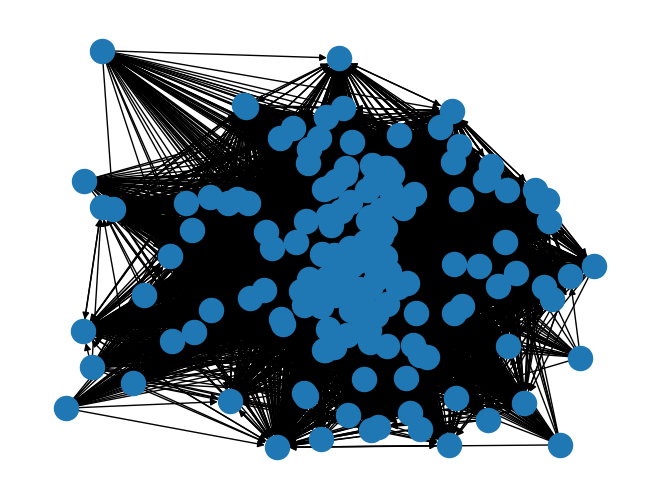

In [11]:
nx.draw(G=graphs_wtn["WDN_1997"])

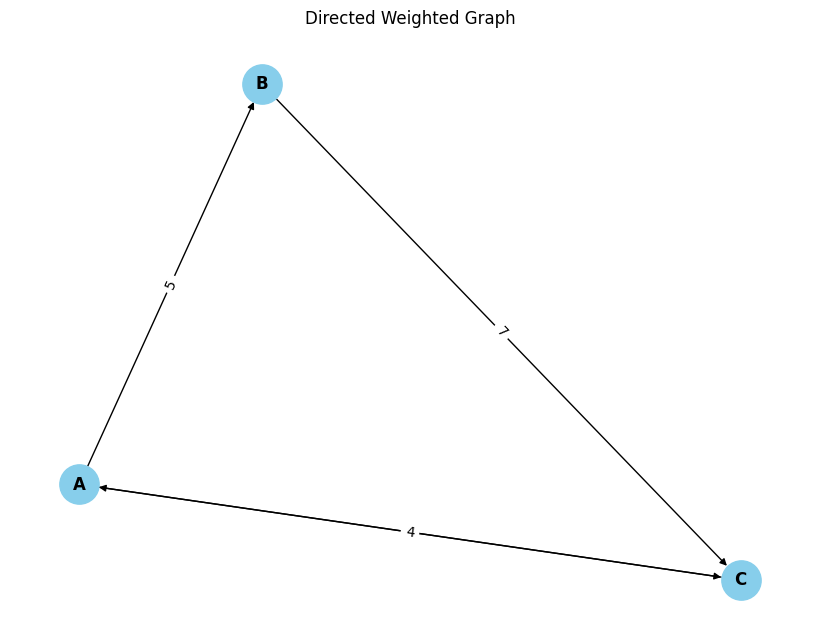

In [21]:
# Example
G = nx.DiGraph()

# Add weighted edges
G.add_edge('A', 'B', weight=5)
G.add_edge('A', 'C', weight=3)
G.add_edge('B', 'C', weight=7)
G.add_edge('C', 'A', weight=4)

# Plot the graph
plt.figure(figsize=(8, 6))

pos = nx.spring_layout(G, seed=42)  # Set the layout for consistent plotting

# Draw nodes and labels
nx.draw(G, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold')

# Draw edge labels with weights
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Directed Weighted Graph')
plt.show()

In [79]:
def calculate_assortativity(graph):
    in_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='in', weight='weight')
    in_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='in', y='out', weight='weight')
    out_in = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='in', weight='weight')
    out_out = nx.assortativity.degree_pearson_correlation_coefficient(G=graph, x='out', y='out', weight='weight')

    # Create a dictionary to store assortativity values
    assortativity_dict = {
        "In-In Assortativity": in_in,
        "In-Out Assortativity": in_out,
        "Out-In Assortativity": out_in,
        "Out-Out Assortativity": out_out
    }

    # Return dictionary with assortativity values
    return assortativity_dict

{'In-In Assortativity': -0.073686352073877,
 'In-Out Assortativity': -0.07132955497657792,
 'Out-In Assortativity': -0.07171683897072376,
 'Out-Out Assortativity': -0.069700798720094}

In [85]:
assortativities = {}
for graph_name, graph in graphs_wtn.items():
    assortativities[graph_name] = calculate_assortativity(graph=graph)
    
print(assortativities)

{'WDN_1997': {'In-In Assortativity': -0.073686352073877, 'In-Out Assortativity': -0.07132955497657792, 'Out-In Assortativity': -0.07171683897072376, 'Out-Out Assortativity': -0.069700798720094}, 'WDN_1992': {'In-In Assortativity': -0.04868776409103533, 'In-Out Assortativity': -0.04664740434092387, 'Out-In Assortativity': -0.05986979308699135, 'Out-Out Assortativity': -0.057603189205412644}, 'WDN_2000': {'In-In Assortativity': -0.0631970717497539, 'In-Out Assortativity': -0.06467170213846346, 'Out-In Assortativity': -0.06539073425903165, 'Out-Out Assortativity': -0.06730072607061886}, 'WDN_1998': {'In-In Assortativity': -0.06557057818395721, 'In-Out Assortativity': -0.06540616504184193, 'Out-In Assortativity': -0.06572057397949527, 'Out-Out Assortativity': -0.06583617855060359}, 'WDN_1994': {'In-In Assortativity': -0.07868988970611884, 'In-Out Assortativity': -0.07622523439269807, 'Out-In Assortativity': -0.0802250161794805, 'Out-Out Assortativity': -0.07800143058821395}, 'WDN_1993': {'

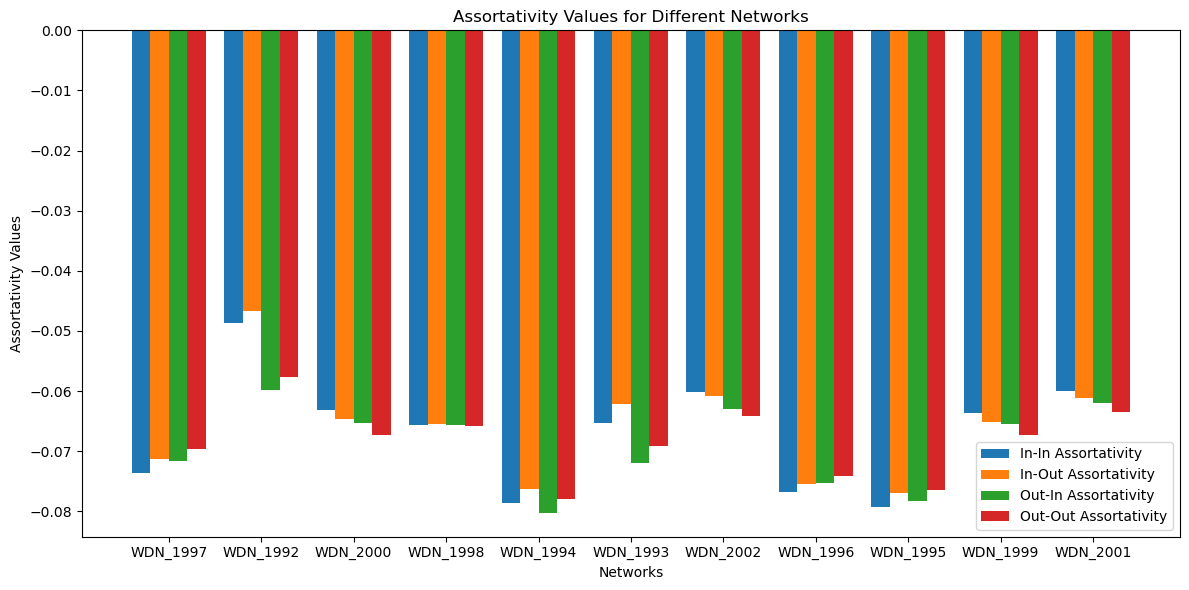

In [86]:
# Extracting graph names and assortativity values
graph_names = list(assortativities.keys())
keys = list(assortativities[graph_names[0]].keys())  # Extracting keys for assortativity values
values = {graph_name: [assortativities[graph_name][key] for key in keys] for graph_name in graph_names}

# Creating side-by-side bar plots for each network
bar_width = 0.2  # Width of each bar
index = np.arange(len(graph_names))  # Index for the networks

plt.figure(figsize=(12, 6))

for i, key in enumerate(keys):
    plt.bar(index + (i * bar_width), [values[graph_name][i] for graph_name in graph_names], bar_width, label=key)

plt.xlabel('Networks')
plt.ylabel('Assortativity Values')
plt.title('Assortativity Values for Different Networks')
plt.xticks(index + (bar_width * (len(keys) - 1) / 2), graph_names)
plt.legend()
plt.tight_layout()

plt.show()

## 2. Fit the Undirected Enhanced CM and Directed Enhanced CM using the CReMa method.
Hint: You can use the nemtropy package on networkx to deploy these methods. You can find some examples
at https://github.com/nicoloval/NEMtropy/blob/master/examples/Directed%20Graphs.
ipynb. For additional questions, do not hesitate to ask at the QA.

## 3. Sample 30 networks from the obtained ERGM distributions and measure the strength assortativity on all of them. Calculate average and standard deviation of each assortativity typology.

## 4. Plot strength assortativity as a function of time (the WTW network year), comparing the observed real value with the average and error bars obtained from the samples samples.
Hint: plot error bars as confidence intervals. Plot all pairs of assortativity for the undirected and directed
case(in-in, in-out, out-out)

## 5. Write a short paragraph to comment on the interpretation of strength assortativity for this dataset, and about the conclusions you can draw via the inference you made using the ERGM models.

Creating Results:
`jupyter nbconvert Assignment_03.ipynb --to pdf --output Assignment_03_Results.pdf`

# Stock correlations

## 1. Is there a market mode at the minute and hour timescale?
Hint: The existence of the market mode is related to the gap between the largest and second largest
eigenvalues of the correlation matrix.


In [9]:
# Load Data
arrays_nyse

{'cormat_1h': array([[ 1.        ,  0.16724079,  0.17792163, ...,  0.0185428 ,
         -0.04161977,  0.157766  ],
        [ 0.16724079,  1.        ,  0.46343185, ...,  0.28985369,
          0.20418909,  0.29171091],
        [ 0.17792163,  0.46343185,  1.        , ...,  0.39057488,
          0.24218336,  0.24357246],
        ...,
        [ 0.0185428 ,  0.28985369,  0.39057488, ...,  1.        ,
          0.42720044,  0.44063307],
        [-0.04161977,  0.20418909,  0.24218336, ...,  0.42720044,
          1.        ,  0.41781517],
        [ 0.157766  ,  0.29171091,  0.24357246, ...,  0.44063307,
          0.41781517,  1.        ]]),
 'cormat_onefactor_1h': array([[1.        , 0.04869414, 0.27441816, ..., 0.16749489, 0.03936576,
         0.16454019],
        [0.04869414, 1.        , 0.22243747, ..., 0.18359562, 0.03585145,
         0.30874494],
        [0.27441816, 0.22243747, 1.        , ..., 0.18981075, 0.02485402,
         0.37026938],
        ...,
        [0.16749489, 0.18359562, 0.1

In [10]:
### NOT SURE IF A LOADED THE RIGHT DATA
cormat_1h = arrays_nyse["cormat_1h"]
cormat_1m = arrays_nyse["cormat_1m"]

# Calculate eigenvalues
eigenvalues_1h = np.linalg.eigvals(cormat_1h)
eigenvalues_1m = np.linalg.eigvals(cormat_1m)

# Sort eigenvalues in descending order
sorted_eigenvalues_1h = np.sort(eigenvalues_1h)[::-1]
sorted_eigenvalues_1m = np.sort(eigenvalues_1m)[::-1]

In [11]:
def getAllGapValues(sorted_eigenvalues):
    result = []
    for i in range(len(sorted_eigenvalues)-1):
        result.append(sorted_eigenvalues[i]-sorted_eigenvalues[i+1])
        
    return result


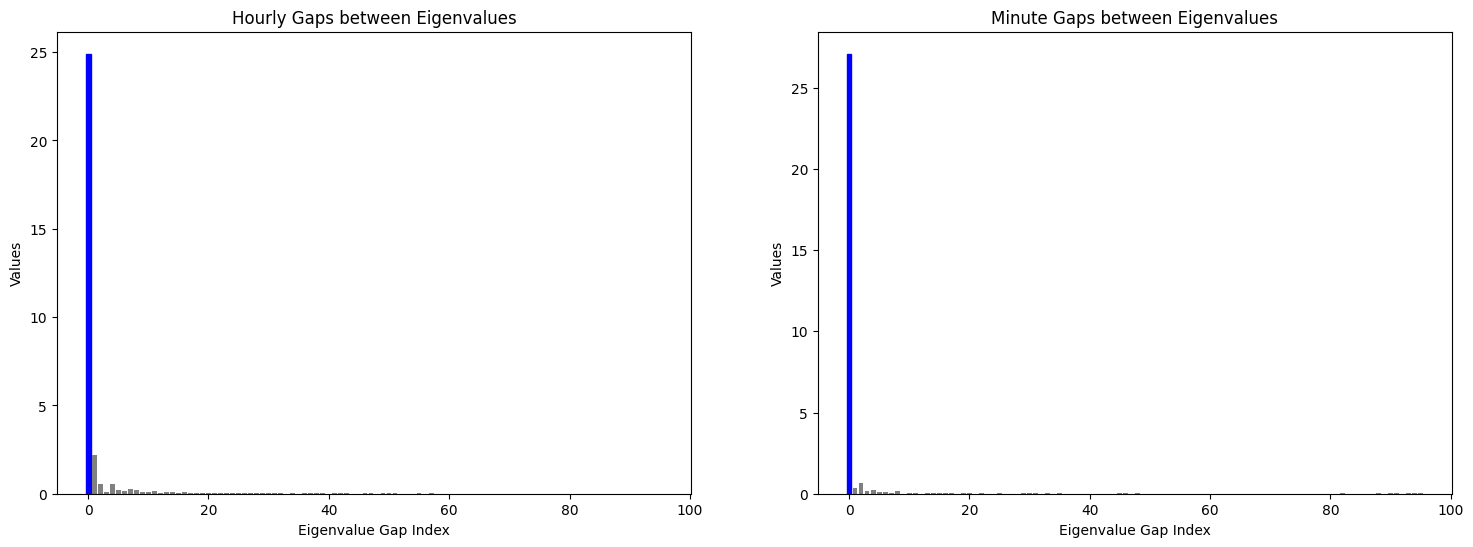

In [12]:
# Get all gaps
hourly_gaps = getAllGapValues(sorted_eigenvalues_1h)
min_gaps = getAllGapValues(sorted_eigenvalues_1m)

# Create a figure with two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot the hourly gaps in the first subplot
bars1 = axs[0].bar(range(len(hourly_gaps)), hourly_gaps, color='gray')  
bars1[0].set_color('blue')  
axs[0].set_xlabel('Eigenvalue Gap Index')
axs[0].set_ylabel('Values')
axs[0].set_title('Hourly Gaps between Eigenvalues')

# Plot the minute gaps in the second subplot
bars2 = axs[1].bar(range(len(min_gaps)), min_gaps, color='gray')  
bars2[0].set_color('blue')  
axs[1].set_xlabel('Eigenvalue Gap Index')
axs[1].set_ylabel('Values')
axs[1].set_title('Minute Gaps between Eigenvalues')

plt.show()

We can clearly see that the first gap is surpassing the others. This suggests the presence of a market mode at both the hour and minute timescales.

##  2. Compute the degree distributions of the 1 hour and 1 minute MSTs. Which are the 5 stocks with highest degree on the two different timescales MST?
Hint: To build the MST, use networkx.minimum_spanning_tree on the weighted undirected graph that is generated by the matrix with entries dij (see lecture on financial networks). 

Assign the correct ticker (AAPL, AMZN, ...) as an attribute to the nodes, by using 
`networkx.set_node_attributes(G, values=tickers, name=’ticker’)`



In [13]:
cormat_1h = arrays_nyse["cormat_1h"]
cormat_1m = arrays_nyse["cormat_1m"]
tickers = stocks

In [14]:
# Prepare the graph data

# Create two weighted graphs
G_1h = nx.Graph()
G_1m = nx.Graph()

# Create a dictionary with tickers as both keys and values
tickers_dict = {ticker: ticker for ticker in tickers}

# Add nodes to the graph
G_1h.add_nodes_from(tickers)
G_1m.add_nodes_from(tickers)

# Set 'ticker' attribute for each node
nx.set_node_attributes(G_1h, tickers_dict, name='ticker')
nx.set_node_attributes(G_1m, tickers_dict, name='ticker')

# Add weighted edges for G_1h
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        weight_1h = cormat_1h[i][j]
        G_1h.add_edge(tickers[i], tickers[j], weight=weight_1h)

# Add weighted edges for G_1m
for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        weight_1m = cormat_1m[i][j]
        G_1m.add_edge(tickers[i], tickers[j], weight=weight_1m)


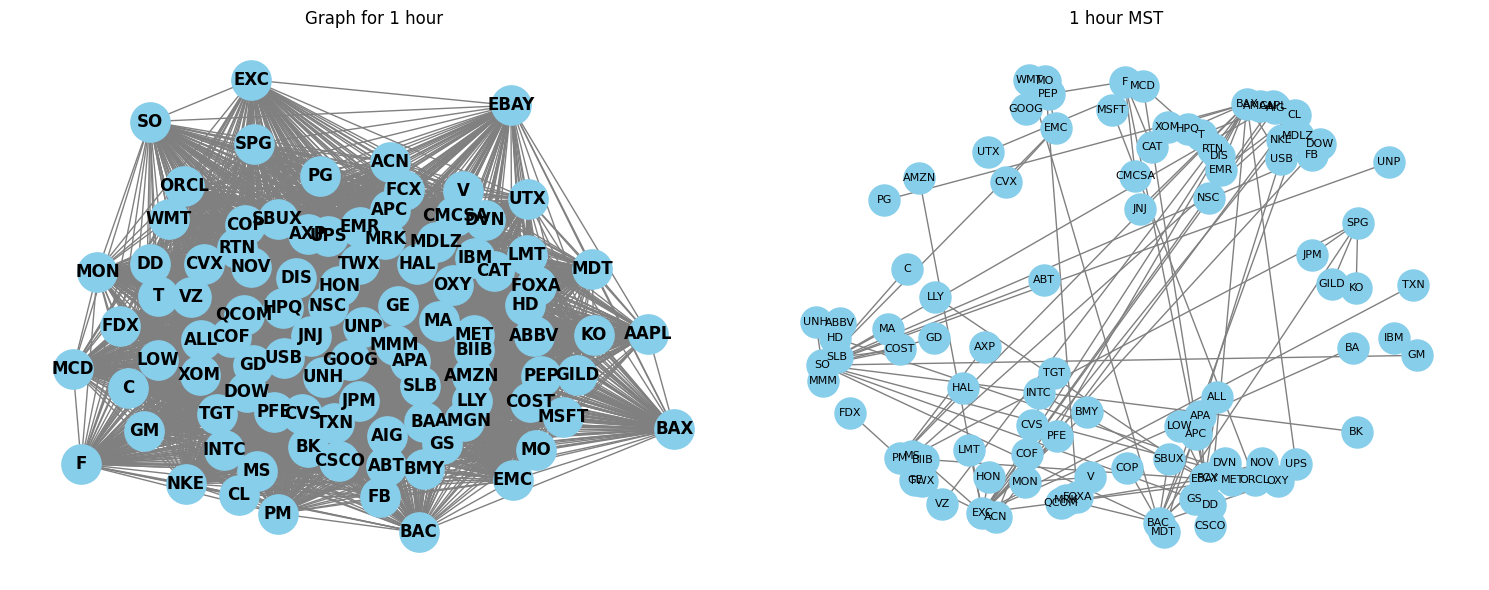

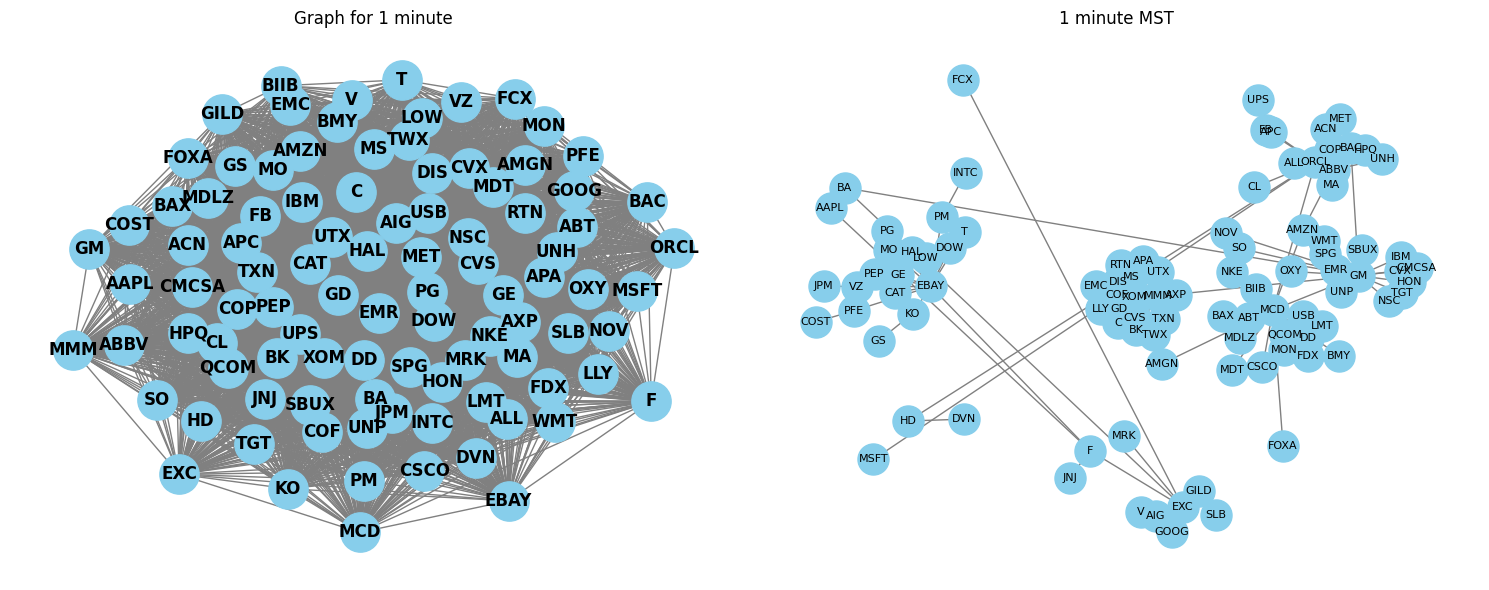

In [15]:
# Show it graphically

# Make MSTs (Cheapest Path to each node)
mst_1h = nx.minimum_spanning_tree(G_1h)

# Subplot for 1h
plt.figure(figsize=(15, 6))

# Plot the G_1h 
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_1h)  # You can choose a different layout if needed
nx.draw(G_1h, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold', edge_color='gray')
plt.title('Graph for 1 hour')

# Plot the mst_1h
plt.subplot(1, 2, 2)
pos = nx.spring_layout(mst_1h)  # You can use different layout algorithms
nx.draw(mst_1h, pos, with_labels=True, font_size=8, font_color='black', node_size=500, node_color='skyblue', edge_color='gray')
plt.title('1 hour MST')

plt.tight_layout()
plt.show()



# Make MSTs (Cheapest Path to each node)
mst_1m = nx.minimum_spanning_tree(G_1m)

# Subplot for 1h
plt.figure(figsize=(15, 6))

# Plot the G_1h 
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_1m)  # You can choose a different layout if needed
nx.draw(G_1m, pos, with_labels=True, node_size=800, node_color='skyblue', font_weight='bold', edge_color='gray')
plt.title('Graph for 1 minute')

# Plot the mst_1h
plt.subplot(1, 2, 2)
pos = nx.spring_layout(mst_1m)  # You can use different layout algorithms
nx.draw(mst_1m, pos, with_labels=True, font_size=8, font_color='black', node_size=500, node_color='skyblue', edge_color='gray')
plt.title('1 minute MST')

plt.tight_layout()
plt.show()


In [16]:
# Print Result

# Compute degree distributions
degree_distribution_1h = dict(mst_1h.degree())
degree_distribution_1m = dict(mst_1m.degree())

# Sort the degree distribution (dict) after descending values
sorted_dict_desc_1h = dict(sorted(degree_distribution_1h.items(), key=lambda item: item[1], reverse=True))
sorted_dict_desc_1m = dict(sorted(degree_distribution_1m.items(), key=lambda item: item[1], reverse=True))

# Print Result
print("Top 5 stocks with highest degree in 1 hour MST:", list(sorted_dict_desc_1h.keys())[:5])
print("Top 5 stocks with highest degree in 1 minute MST:", list(sorted_dict_desc_1m.keys())[:5])

Top 5 stocks with highest degree in 1 hour MST: ['SO', 'EXC', 'BAX', 'BAC', 'EBAY']
Top 5 stocks with highest degree in 1 hour MST: ['MCD', 'GM', 'MMM', 'EBAY', 'EXC']


## 3. Plot the degree distributions at 1 minute and 1 hour. Are the degree distributions qualitatively the same? Provide a comment to explain eventual similarities or dissimilarities.

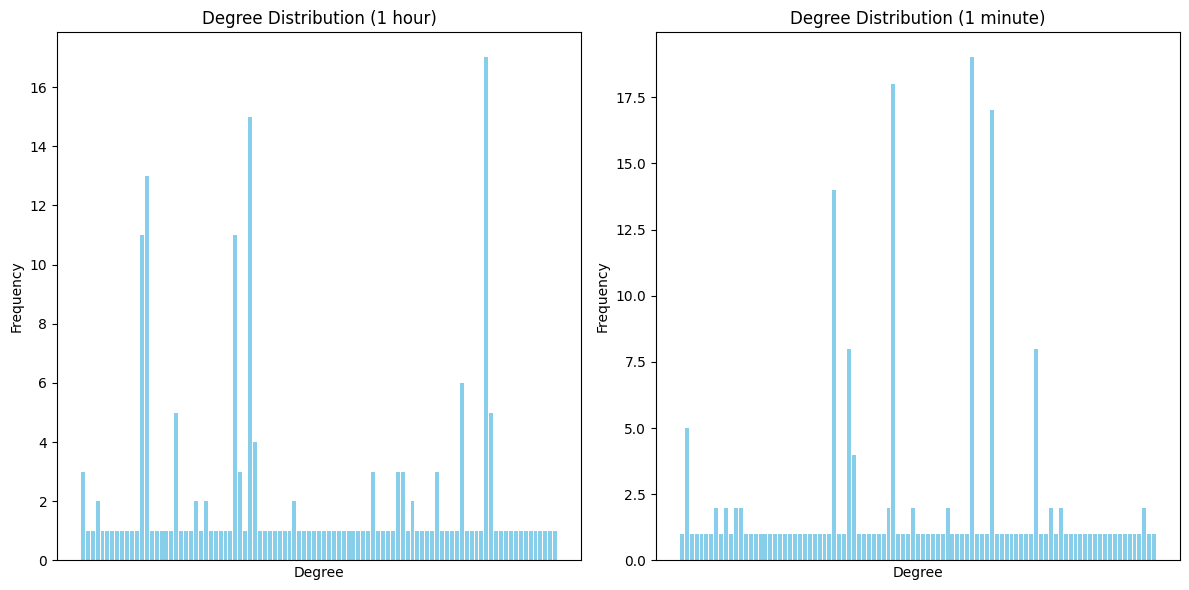

Sorted Dict which shows which node has which degree:
{'SO': 17, 'EXC': 15, 'BAX': 13, 'BAC': 11, 'EBAY': 11, 'PM': 6, 'CL': 5, 'SPG': 5, 'F': 4, 'AAPL': 3, 'EMC': 3, 'MCD': 3, 'MO': 3, 'MON': 3, 'ORCL': 3, 'ACN': 2, 'COST': 2, 'CVS': 2, 'GM': 2, 'MS': 2, 'ABBV': 1, 'ABT': 1, 'AIG': 1, 'ALL': 1, 'AMGN': 1, 'AMZN': 1, 'APA': 1, 'APC': 1, 'AXP': 1, 'BA': 1, 'BIIB': 1, 'BK': 1, 'BMY': 1, 'C': 1, 'CAT': 1, 'CMCSA': 1, 'COF': 1, 'COP': 1, 'CSCO': 1, 'CVX': 1, 'DD': 1, 'DIS': 1, 'DOW': 1, 'DVN': 1, 'EMR': 1, 'FB': 1, 'FCX': 1, 'FDX': 1, 'FOXA': 1, 'GD': 1, 'GE': 1, 'GILD': 1, 'GOOG': 1, 'GS': 1, 'HAL': 1, 'HD': 1, 'HON': 1, 'HPQ': 1, 'IBM': 1, 'INTC': 1, 'JNJ': 1, 'JPM': 1, 'KO': 1, 'LLY': 1, 'LMT': 1, 'LOW': 1, 'MA': 1, 'MDLZ': 1, 'MDT': 1, 'MET': 1, 'MMM': 1, 'MRK': 1, 'MSFT': 1, 'NKE': 1, 'NOV': 1, 'NSC': 1, 'OXY': 1, 'PEP': 1, 'PFE': 1, 'PG': 1, 'QCOM': 1, 'RTN': 1, 'SBUX': 1, 'SLB': 1, 'T': 1, 'TGT': 1, 'TWX': 1, 'TXN': 1, 'UNH': 1, 'UNP': 1, 'UPS': 1, 'USB': 1, 'UTX': 1, 'V': 1, 'VZ': 1

In [17]:
# Plot degree distributions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(degree_distribution_1h.keys(), degree_distribution_1h.values(), color='skyblue')
plt.title('Degree Distribution (1 hour)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.xticks([])  # Remove x-axis labels

plt.subplot(1, 2, 2)
plt.bar(degree_distribution_1m.keys(), degree_distribution_1m.values(), color='skyblue')
plt.title('Degree Distribution (1 minute)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.xticks([])  # Remove x-axis labels

plt.tight_layout()
plt.show()

print("Sorted Dict which shows which node has which degree:")
print(sorted_dict_desc_1h)
print(sorted_dict_desc_1m)

TODO with NICI

Similarities: Both MST have roughly the same amount of nodes which habe a high degree and which are edges. So they look pretty similar.

Dissimilarities: Besides that they have different nodes which have a high degree, one additional dissimilarity is that in the 1 minute MST there is a more central node (19 edges). It is also in general less connected than the other one hour one.

## 4. Compare the MST degree distributions of the 1 hour, 1 minute, Normal and One-Factor correlations: for each time scale, plot the three different distributions on the same plot. Is the degree distribution of MSTs well reproduced by the null Gaussian and One-Factor models?


In [18]:
len(arrays_nyse["cormat_gaussian_1h"])


97

In [19]:
# Same as in 2.3 but in a function
def calculate_degree_distribution(data):
    G = nx.Graph()

    G.add_nodes_from(tickers)

    nx.set_node_attributes(G, tickers_dict, name='ticker')

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            weight = data[i][j]
            G.add_edge(tickers[i], tickers[j], weight=weight)

    mst = nx.minimum_spanning_tree(G)

    degree_distribution = dict(mst.degree())

    return degree_distribution

In [20]:
degree_distribution_gaussian_1h = calculate_degree_distribution(arrays_nyse["cormat_gaussian_1h"])
degree_distribution_gaussian_1m = calculate_degree_distribution(arrays_nyse["cormat_gaussian_1m"])
degree_distribution_onefactor_1h = calculate_degree_distribution(arrays_nyse["cormat_onefactor_1h"])
degree_distribution_onefactor_1m = calculate_degree_distribution(arrays_nyse["cormat_onefactor_1m"])

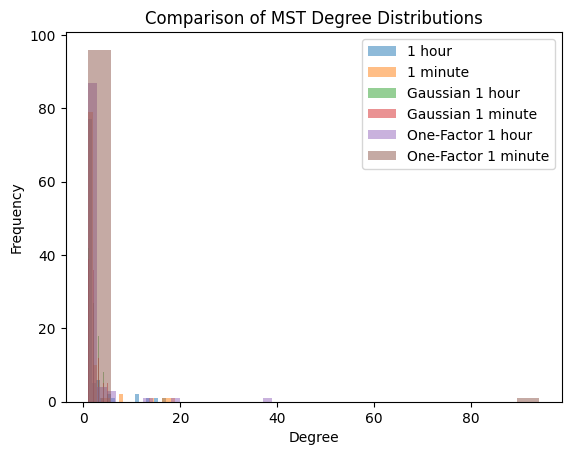

In [21]:

def plot_degree_distribution(degree_distribution, label):
    plt.hist(list(degree_distribution.values()), bins=20, alpha=0.5, label=label)

# Plot the degree distributions
plot_degree_distribution(degree_distribution_1h, '1 hour')
plot_degree_distribution(degree_distribution_1m, '1 minute')
plot_degree_distribution(degree_distribution_gaussian_1h, 'Gaussian 1 hour')
plot_degree_distribution(degree_distribution_gaussian_1m, 'Gaussian 1 minute')
plot_degree_distribution(degree_distribution_onefactor_1h, 'One-Factor 1 hour')
plot_degree_distribution(degree_distribution_onefactor_1m, 'One-Factor 1 minute')

# Add labels and legend
plt.legend()
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.title('Comparison of MST Degree Distributions')
plt.show()

In [22]:
print(dict(sorted(degree_distribution_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_gaussian_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_gaussian_1m.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1h.items(), key=lambda item: item[1], reverse=True)))
print(dict(sorted(degree_distribution_onefactor_1m.items(), key=lambda item: item[1], reverse=True)))

{'SO': 17, 'EXC': 15, 'BAX': 13, 'BAC': 11, 'EBAY': 11, 'PM': 6, 'CL': 5, 'SPG': 5, 'F': 4, 'AAPL': 3, 'EMC': 3, 'MCD': 3, 'MO': 3, 'MON': 3, 'ORCL': 3, 'ACN': 2, 'COST': 2, 'CVS': 2, 'GM': 2, 'MS': 2, 'ABBV': 1, 'ABT': 1, 'AIG': 1, 'ALL': 1, 'AMGN': 1, 'AMZN': 1, 'APA': 1, 'APC': 1, 'AXP': 1, 'BA': 1, 'BIIB': 1, 'BK': 1, 'BMY': 1, 'C': 1, 'CAT': 1, 'CMCSA': 1, 'COF': 1, 'COP': 1, 'CSCO': 1, 'CVX': 1, 'DD': 1, 'DIS': 1, 'DOW': 1, 'DVN': 1, 'EMR': 1, 'FB': 1, 'FCX': 1, 'FDX': 1, 'FOXA': 1, 'GD': 1, 'GE': 1, 'GILD': 1, 'GOOG': 1, 'GS': 1, 'HAL': 1, 'HD': 1, 'HON': 1, 'HPQ': 1, 'IBM': 1, 'INTC': 1, 'JNJ': 1, 'JPM': 1, 'KO': 1, 'LLY': 1, 'LMT': 1, 'LOW': 1, 'MA': 1, 'MDLZ': 1, 'MDT': 1, 'MET': 1, 'MMM': 1, 'MRK': 1, 'MSFT': 1, 'NKE': 1, 'NOV': 1, 'NSC': 1, 'OXY': 1, 'PEP': 1, 'PFE': 1, 'PG': 1, 'QCOM': 1, 'RTN': 1, 'SBUX': 1, 'SLB': 1, 'T': 1, 'TGT': 1, 'TWX': 1, 'TXN': 1, 'UNH': 1, 'UNP': 1, 'UPS': 1, 'USB': 1, 'UTX': 1, 'V': 1, 'VZ': 1, 'WMT': 1, 'XOM': 1}
{'MCD': 19, 'GM': 18, 'MMM': 17

TODO with NICI:

Is the degree distribution of MSTs well reproduced by the null Gaussian and One-Factor models?

Not that much. 